
https://onlinelibrary.wiley.com/doi/full/10.1111/ejn.70521

EEG recording took place in a room fully equipped to minimize noise, electromagnetic interference, and environmental influences, providing an optimal setting for the procedure. Continuous EEG activity was recorded from 

60 homogeneously distributed electrodes (10–10 system)

Vertical and horizontal eye movements were monitored through electrooculographic (EOG) 
The vertical EOG electrodes were positioned both below and above the left eye orbit, while the 
horizontal EOG electrodes were situated on the left and right orbital rims. 

Electrode impedances were maintained below 5 kΩ, and a 
bandpass filter of 0.1–50 Hz (3 dB points for −6 dB/octave roll-off) Data were continuously digitized at a sampling rate of 250 Hz. 

Offline preprocessing was performed using a custom MATLAB R2023b (The MathWorks Inc. 2023) script containing EEGLAB v2023.1 (Delorme and Makeig 2004) functions.

In [4]:
# !pip install matplotlib
!pip install mne

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/7.4 MB ? eta -:--:--
   ---------------------------------------- 7.4/7.4 MB 75.7 MB/s  0:00:00
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   --- ------------------------------------  1/11 [tqdm]
   -------------- -------------------------  4/11 [idna]
   ----------------------------- ----------  8/11 [jinja2]
   ------------------------------------ --- 10/11 [mne]
   ------------------------------------ --- 10/11 [mne]
   ------------------------------------ --- 10/11 [mne]
   ------------------------------------ --- 10/11 [mne]
   ------------------------------------ --- 10/11 [mne]
   ------------------------------------ --- 10/11 [mne]
   ------------------------------------ --- 10/11 [mne]
   ------------------------------------ --- 10/11 [mne]


In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
import mne, glob

In [13]:
#find matfiles in the current directory

matfiles = glob.glob('*.mat')

data = {}
matfiles

['sub04-FM.mat', 'sub05-FM.mat']

In [14]:
# load the .mat file
dat = loadmat(matfiles[1])

# EEG structure
eeg_struct = dat['EEG'][0, 0]

# find datamatrix
real_data = eeg_struct['data']

# Transpose to MNE standard: (trials, channels, time)
data_mne = np.transpose(real_data, (2, 0, 1))

In [15]:
# channels x time x trials
X = dat['X']
Y = dat['Y']  

KeyError: 'X'

In [8]:
# Converteer de signaalsterkte van microvolts (EEGLAB) naar Volts (MNE)
data_mne_volts = data_mne * 1e-6

# 6. Haal de sampling rate uit de structuur
srate = eeg_struct['srate'].item() 

# 7. Creëer de MNE Info structuur (met 60 dummy kanaalnamen voor nu)
info = mne.create_info(ch_names=60, sfreq=srate, ch_types='eeg')

# 8. Bouw het definitieve MNE Epochs object!
epochs = mne.EpochsArray(data_mne_volts, info)

# Print het resultaat om te controleren of MNE het goed heeft geaccepteerd
print(epochs)

Not setting metadata
96 matching events found
No baseline correction applied
0 projection items activated
<EpochsArray | 96 events (all good), 0 – 1.344 s (baseline off), ~14.9 MB, data loaded,
 '1': 96>


Using matplotlib as 2D backend.


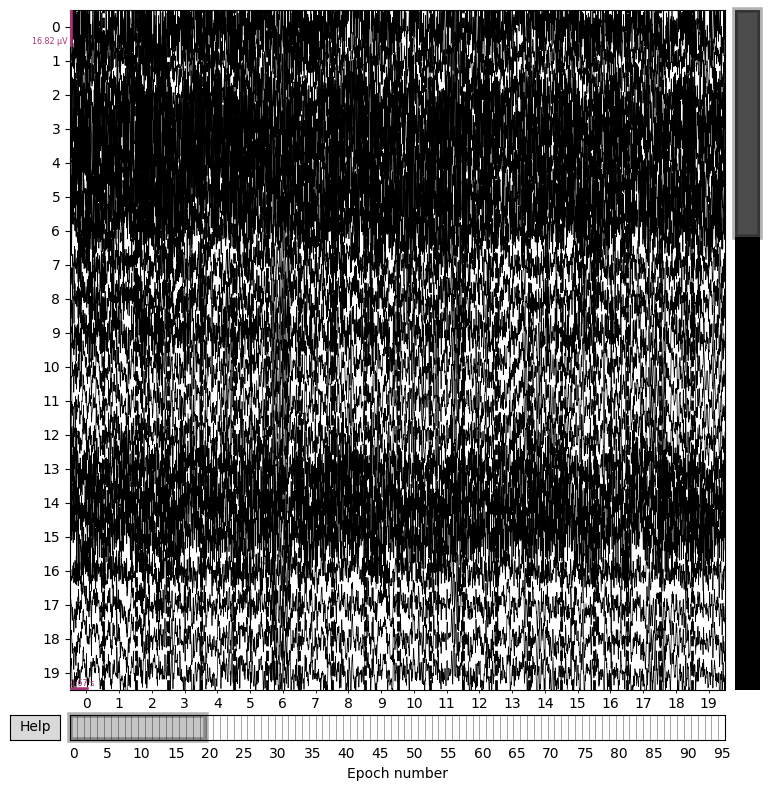

In [9]:
# scalings='auto' is handig zodat MNE zelf de y-as schaal aanpast aan jouw voltages
epochs.plot(scalings='auto')
plt.show()

Not setting metadata
96 matching events found
No baseline correction applied
0 projection items activated


C:\Users\Jasmyne\AppData\Local\Temp\ipykernel_33848\1972601538.py:1: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  epochs.plot_image(picks=[0])


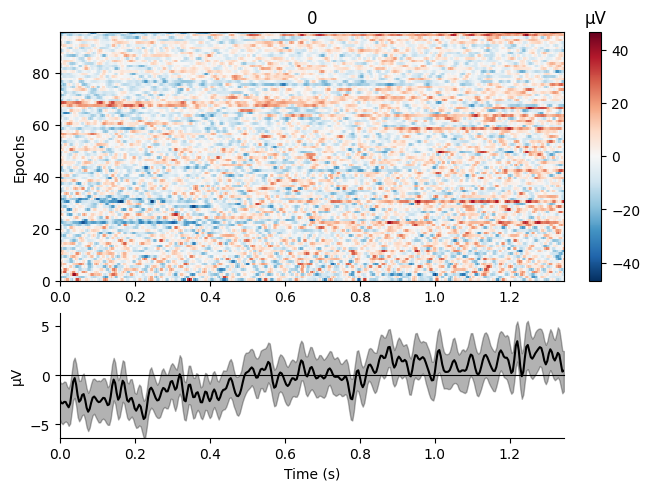

In [35]:
epochs.plot_image(picks=[0])
plt.show()

C:\Users\Jasmyne\AppData\Local\Temp\ipykernel_33848\370352039.py:5: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked.plot(spatial_colors=True)


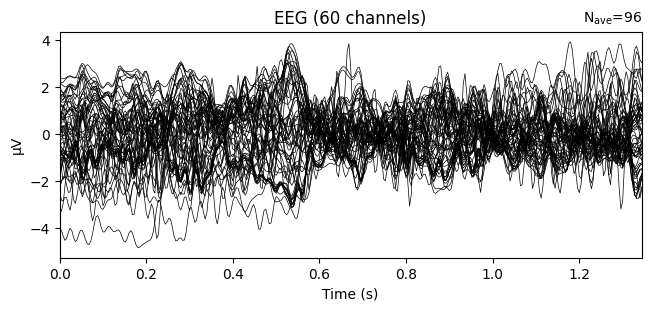

In [37]:
# Bereken het gemiddelde over alle 96 trials
evoked = epochs.average()

# Plot het gemiddelde (ziet er vaak veel schoner uit!)
evoked.plot(spatial_colors=True)
plt.show()

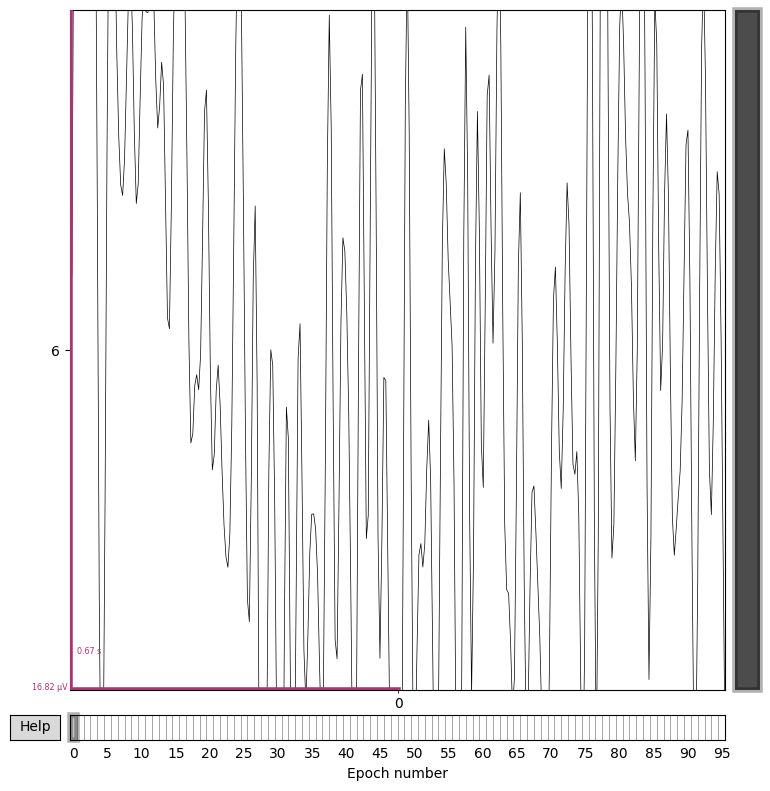

In [42]:
# picks=[0] selecteert het eerste kanaal uit je 60 kanalen
# n_epochs=1 laat alleen de eerste trial zien
epochs.plot(picks=[6], n_epochs=1, scalings='auto')
plt.show()

In [43]:
# 1. Extraheer de kanaalnamen uit de EEGLAB-structuur
# In scipy.io.loadmat is 'chanlocs' een array van records
chan_info = eeg_struct['chanlocs'][0]
ch_names = [chan['labels'][0] for chan in chan_info]

In [44]:
# 2. Update de MNE Info structuur met de echte namen
# We gebruiken de eerder gevonden 'srate'
info = mne.create_info(ch_names=ch_names, sfreq=srate, ch_types='eeg')

In [45]:
# 3. Re-creëer het MNE Epochs object (met de Volt-gecorrigeerde data)
epochs = mne.EpochsArray(data_mne_volts, info)

Not setting metadata
96 matching events found
No baseline correction applied
0 projection items activated


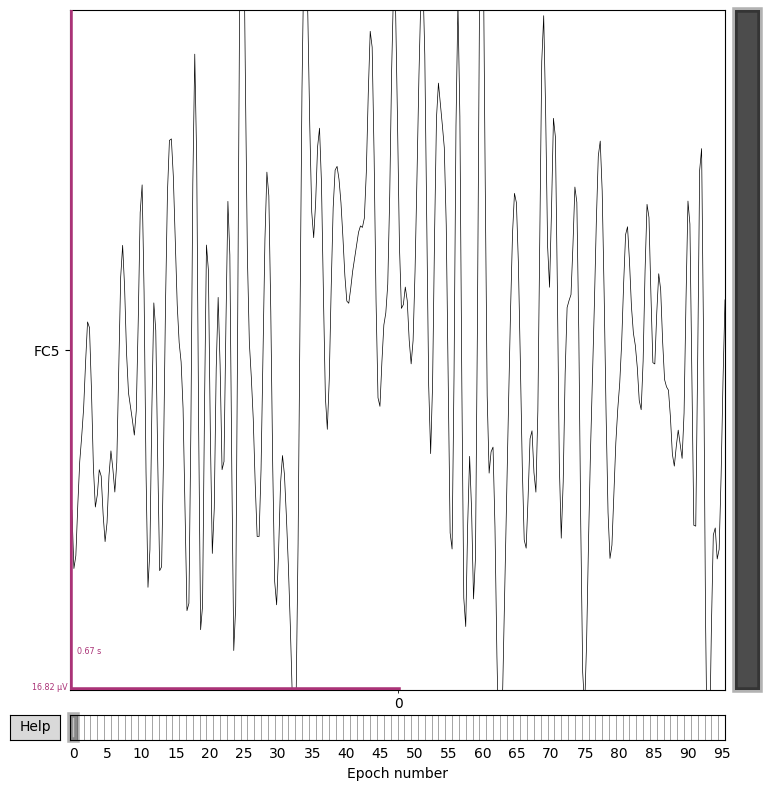

In [46]:
# 4. Visualisatie zoals in jouw geüploade notebook
# Je kunt nu specifieke kanalen aanroepen met hun naam
# Let op: controleer met print(epochs.ch_names) of 'FC5' in deze set zit
try:
    epochs.plot(picks=["FC5"], n_epochs=1, scalings='auto', title="Visualisatie Kanaal FC5")
except ValueError:
    print(f"Kanaal 'FC5' niet gevonden. Beschikbare kanalen: {epochs.ch_names[:5]}...")
    # Plot dan gewoon de eerste paar kanalen
    epochs.plot(n_channels=10, n_epochs=1, scalings='auto')

Toelichting op de methodologie
Metadata Extractie: De chanlocs structuur in MATLAB bevat voor elk kanaal een 'label'. Door een list comprehension in Python te gebruiken, transformeren we deze MATLAB-velden naar een lijst met strings die MNE begrijpt.

MNE-Python Standaarden: MNE hanteert strikte standaarden voor kanaalidentificatie. Door de juiste namen in de info structuur te plaatsen, kun je functies zoals epochs.plot_sensors() gebruiken om de fysieke positie van de sensoren op de schedel te verifiëren.

Visualisatie: In jouw notebook werd n_epochs=1 gebruikt. Dit is een effectieve manier om individuele trials te inspecteren op artefacten (zoals oogknipperingen of spieractiviteit) voordat verdere statistische analyses worden uitgevoerd.

In [47]:
print(eeg_struct.dtype.names)

('setname', 'filename', 'filepath', 'subject', 'group', 'condition', 'session', 'comments', 'nbchan', 'trials', 'pnts', 'srate', 'xmin', 'xmax', 'times', 'data', 'icaact', 'icawinv', 'icasphere', 'icaweights', 'icachansind', 'chanlocs', 'urchanlocs', 'chaninfo', 'ref', 'event', 'urevent', 'eventdescription', 'epoch', 'epochdescription', 'reject', 'stats', 'specdata', 'specicaact', 'splinefile', 'icasplinefile', 'dipfit', 'history', 'saved', 'etc', 'run', 'roi')
